# Baseline Logistic Regression — Telecom Customer Churn

This notebook establishes the first machine-learning baseline for the
B2B telecom customer churn prediction project.

Objectives:
- Reuse the production data-preparation code in `src/`
- Create a reproducible stratified train/test split
- Build a leakage-safe sklearn preprocessing + Logistic Regression pipeline
- Evaluate churn probabilities using PR-AUC, ROC-AUC, precision, recall, and F1
- Establish a baseline for comparison with future models

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

# Make the project root importable from the notebook
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessing import (
    build_preprocessor,
    load_raw_data,
    prepare_dataset,
)
from src.data.split import create_train_test_split

In [2]:
df = load_raw_data()

print(f'Database Shape: {df.shape}')

Database Shape: (8453, 14)


In [3]:
X, y = prepare_dataset(df)

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print()
print("Features:")
print(X.columns.tolist())
print()
print("Target distribution:")
print(y.value_counts())

Feature shape: (8453, 9)
Target shape: (8453,)

Features:
['CRM_PID_Value_Segment', 'EffectiveSegment', 'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU']

Target distribution:
CHURN
0    7904
1     549
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print()
print("Training churn rate:", y_train.mean())
print("Test churn rate:    ", y_test.mean())

Training set: (6762, 9)
Test set:     (1691, 9)

Training churn rate: 0.06492162082224194
Test churn rate:     0.06505026611472502


## Build the Baseline Model

The preprocessing transformer and Logistic Regression classifier are combined
into a single sklearn Pipeline.

The preprocessing is fitted only when the pipeline is trained on `X_train`.
The test set is used only for transformation and evaluation.

In [5]:
baseline_model = Pipeline(
    steps=[
        ('Preprocessor', build_preprocessor(scale_numeric=True)),
        ('Classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## Train the Baseline Model

The pipeline is fitted using training data only.

No information from `X_test` or `y_test` is used during training.

In [6]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['CRM_PID_Value_Segment','EffectiveSegment','Active_subscribers',..., 'AvgMobileRevenue','AvgFIXRevenue','ARPU']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [7]:
y_proba = baseline_model.predict_proba(X_test)[:, 1]

y_pred = baseline_model.predict(X_test)

print("Probability range:")
print(f"Minimum: {y_proba.min():.4f}")
print(f"Maximum: {y_proba.max():.4f}")

print()
print("Predicted positive class count:", y_pred.sum())

Probability range:
Minimum: 0.0051
Maximum: 0.2829

Predicted positive class count: 0


In [9]:
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

baseline_metrics = pd.Series(
    {
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }
)

baseline_metrics

PR-AUC       0.082143
ROC-AUC      0.559192
Precision    0.000000
Recall       0.000000
F1           0.000000
dtype: float64

In [10]:
print("Actual churners in test set:", y_test.sum())
print("Predicted churners:", y_pred.sum())
print("Maximum predicted churn probability:", y_proba.max())

print("\nProbability summary:")
print(pd.Series(y_proba).describe())

Actual churners in test set: 110
Predicted churners: 0
Maximum predicted churn probability: 0.2828668342393213

Probability summary:
count    1691.000000
mean        0.065224
std         0.020359
min         0.005125
25%         0.051015
50%         0.059750
75%         0.074604
max         0.282867
dtype: float64


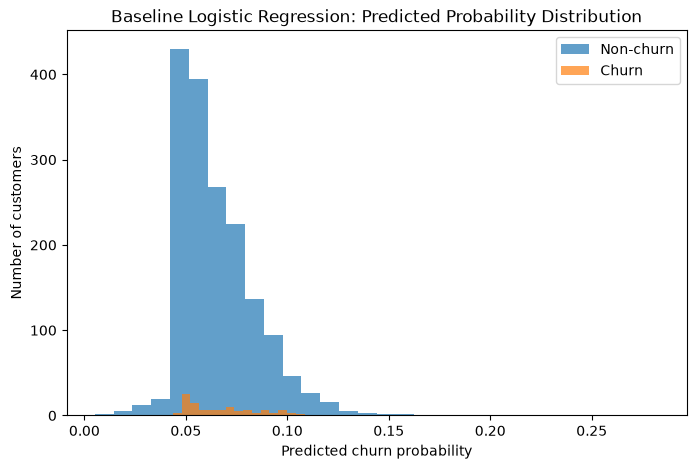

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(y_proba, bins=30, alpha=0.7, label='Non-churn')

plt.hist(y_proba[y_test == 1], bins=30, alpha=0.7, label='Churn')

plt.xlabel("Predicted churn probability")
plt.ylabel("Number of customers")
plt.title("Baseline Logistic Regression: Predicted Probability Distribution")
plt.legend()
plt.show()

### Precision-Recall Curve

Because churn is an imbalanced target, the precision-recall curve provides
a more informative view of model behavior across classification thresholds.

The curve is used here as a diagnostic. We will not select a production
threshold using the test set, because that would introduce test-set
information into model decisions.

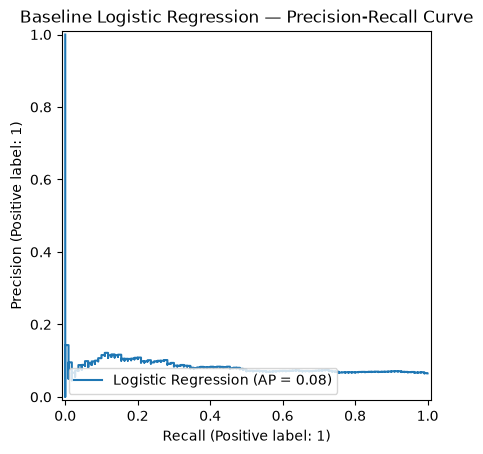

In [13]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="Logistic Regression"
)

plt.title("Baseline Logistic Regression — Precision-Recall Curve")
plt.show()

### Top-Risk Customer Capture

A churn model is ultimately used to prioritize customers for retention action.

This diagnostic measures how many actual churners appear within the
highest-risk portions of the ranked test set.

The test set is used here for baseline diagnosis only; it will not be used
to select the production decision threshold.

In [14]:
risk_table = pd.DataFrame(
    {
        "actual_churn": y_test.to_numpy(),
        "predicted_probability": y_proba,
    }
).sort_values(
    "predicted_probability",
    ascending=False
)

risk_table["cumulative_churners"] = risk_table["actual_churn"].cumsum()
risk_table["customer_rank"] = range(1, len(risk_table) + 1)

risk_table["cumulative_recall"] = (
    risk_table["cumulative_churners"] / y_test.sum()
)

risk_table.head(20)

,actual_churn,predicted_probability,cumulative_churners,customer_rank,cumulative_recall
813,0,0.282867,0,1,0.000000
991,0,0.239234,0,2,0.000000
26,0,0.211696,0,3,0.000000
566,0,0.180527,0,4,0.000000
224,0,0.167511,0,5,0.000000
1078,0,0.160829,0,6,0.000000
169,1,0.160520,1,7,0.009091
1669,0,0.148410,1,8,0.009091
608,0,0.146318,1,9,0.009091
174,0,0.138303,1,10,0.009091


### Top-Risk Customer Capture

This analysis evaluates how effectively the model concentrates actual churners
within the highest-risk customers.

The analysis is reported at fixed customer-coverage levels rather than using
an arbitrary probability threshold.

In [15]:
coverage_levels = [0.05, 0.10, 0.20, 0.30]

total_churners = y_test.sum()
total_customers = len(y_test)

capture_results = []

for coverage in coverage_levels:
    n_customers = int(total_customers * coverage)

    top_customers = risk_table.head(n_customers)

    captured_churners = top_customers["actual_churn"].sum()
    recall_at_coverage = captured_churners / total_churners

    precision_at_coverage = (
        captured_churners / n_customers
        if n_customers > 0
        else 0
    )

    capture_results.append(
        {
            "Coverage": coverage,
            "Customers": n_customers,
            "Churners Captured": captured_churners,
            "Recall": recall_at_coverage,
            "Precision": precision_at_coverage,
        }
    )

capture_results = pd.DataFrame(capture_results)

capture_results

,Coverage,Customers,Churners Captured,Recall,Precision
0,0.05,84,7,0.063636,0.083333
1,0.10,169,17,0.154545,0.100592
2,0.20,338,31,0.281818,0.091716
3,0.30,507,42,0.381818,0.082840


## Baseline Summary

The initial Logistic Regression baseline shows limited but measurable
churn-ranking ability.

Key results:

- PR-AUC: 0.0821
- ROC-AUC: 0.5592
- Precision at 0.50 threshold: 0.0000
- Recall at 0.50 threshold: 0.0000
- F1 at 0.50 threshold: 0.0000
- Top 10% risk-group recall: 15.45%
- Top 20% risk-group recall: 28.18%
- Top 30% risk-group recall: 38.18%

The default 0.50 classification threshold produces no positive predictions.
Because churn is highly imbalanced, future threshold selection will be based
on validation data and the intended business operating point rather than the
default threshold.

This model serves as the initial benchmark for subsequent models.